# Problem 398 - Cutting Rope
Inside a rope of length $n$, $n - 1$ points are placed with distance $1$ from each other and from the endpoints. Among these points, we choose $m - 1$ points at random and cut the rope at these points to create $m$ segments.

Let $E(n, m)$ be the expected length of the second-shortest segment.
For example, $E(3, 2) = 2$ and $E(8, 3) = 16/7$.
Note that if multiple segments have the same shortest length the length of the second-shortest segment is defined as the same as the shortest length.

Find $E(10^7, 100)$.
Give your answer rounded to $5$ decimal places behind the decimal point.


## Solution.


In [5]:
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 1000000/1000000 [00:56<00:00, 17665.89it/s]


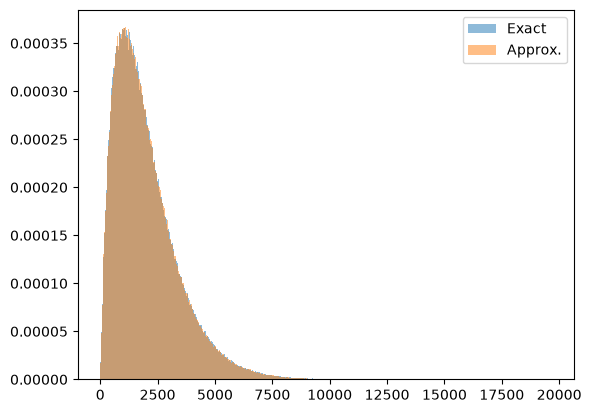

(2012.369679, 2007.9533914679214)

In [12]:
def MC(n, m, N=100_000):
    X_exact, X_approx = [], []

    for _ in tqdm(range(N)):
        B = [0] + sorted(random.sample(range(1, n), m - 1)) + [n]
        X = [B[i] - B[i-1] for i in range(1, m + 1)]
        X_exact.append(sorted(X)[1])

        U = [0] + sorted(random.random() for _ in range(m - 1)) + [1]
        X = [n * (U[i] - U[i-1]) for i in range(1, m + 1)]
        X_approx.append(sorted(X)[1])

    plt.hist(X_exact, bins="auto", density=True, alpha=.5, label="Exact")
    plt.hist(X_approx, bins="auto", density=True, alpha=.5, label="Approx.")
    plt.legend()
    plt.show()

    return sum(X_exact)/N, sum(X_approx)/N

MC(10**7, 100, 1_000_000)